In [56]:
# Nhập thư viện TensorFlow để xây dựng mô hình Deep Learning và các tiện ích xử lý dữ liệu
import tensorflow as tf

# Nhập thư viện Pandas để đọc, xử lý và phân tích dữ liệu dạng bảng (DataFrame)
import pandas as pd

# Nhập thư viện os để thực hiện các thao tác kiểm tra đường dẫn và quản lý thư mục hệ thống
import os

# Nhập TextVectorization để chuyển đổi văn bản thô thành chuỗi chỉ số số nguyên (Token ID)
from tensorflow.keras.layers import TextVectorization

# Nhập projector từ TensorBoard để hỗ trợ xuất file trực quan hóa vector nhúng (Embedding) trong không gian 3D
from tensorboard.plugins import projector

# Đường dẫn URL lưu trữ file dữ liệu IMDB Dataset dạng CSV trực tuyến
url = "https://storage.googleapis.com/protonx-cloud-storage/datasets/IMDB%20Dataset.csv"

# Tên file CSV đích sẽ được lưu ở thư mục làm việc cục bộ
csv_path = "IMDB Dataset.csv"

# Kiểm tra nếu file dữ liệu IMDB Dataset.csv chưa tồn tại ở thư mục hiện tại thì mới tiến hành tải
if not os.path.exists(csv_path):
    print("Đang tải dữ liệu IMDB...")
    # Tải file từ url về và lưu ngay tại thư mục hiện tại (cache_dir="." và không tạo thư mục con cache_subdir="")
    tf.keras.utils.get_file(csv_path, origin=url, cache_dir=".", cache_subdir="")

# Sử dụng thư viện Pandas để đọc file CSV vừa tải về vào biến df (DataFrame)
df = pd.read_csv(csv_path)

In [57]:
# Nhập thư viện NLTK (Natural Language Toolkit) phục vụ cho các tác vụ xử lý ngôn ngữ tự nhiên cơ bản
import nltk

# Tải gói dữ liệu 'punkt' hỗ trợ việc tách từ (tokenization) câu/từ trong NLTK
nltk.download('punkt')

# Tải danh sách từ dừng 'stopwords' (các từ phổ biến ít mang ý nghĩa ngữ nghĩa như: is, are, the,...) để lọc bỏ
nltk.download('stopwords')

# Tải bộ dữ liệu 'punkt_tab' cần thiết cho các phiên bản NLTK mới để thực hiện việc tokenizer
nltk.download('punkt_tab')

# Nhập module stopwords từ NLTK để truy xuất danh sách từ dừng của các ngôn ngữ
from nltk.corpus import stopwords

# Nhập WordNetLemmatizer để thực hiện việc chuẩn hóa từ về dạng gốc (lemmatization), ví dụ: "running" -> "run"
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [58]:
# Chạy lệnh hệ thống pip để cài đặt thư viện fasttext (thư viện NLP của Facebook chuyên phân loại văn bản cực nhanh)
!pip install fasttext

In [59]:
# Nhập lại thư viện Pandas để thực hiện các thao tác xử lý trên bảng dữ liệu (DataFrame)
import pandas as pd

# Nhập hàm train_test_split từ Scikit-learn để hỗ trợ chia tập dữ liệu thành 2 phần: huấn luyện (train) và kiểm tra (test)
from sklearn.model_selection import train_test_split

# Tạo cột mới tên là 'label' bằng cách nối chuỗi '__label__' trước giá trị của cột 'sentiment' (positive/negative)
# FastText yêu cầu nhãn của dữ liệu giám sát phải có dạng tiền tố mặc định là '__label__'
df['label'] = '__label__'+ df['sentiment']

# Hiển thị bảng dữ liệu df sau khi thêm cột nhãn để kiểm tra kết quả
df

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,__label__positive
1,A wonderful little production. <br /><br />The...,positive,__label__positive
2,I thought this was a wonderful way to spend ti...,positive,__label__positive
3,Basically there's a family where a little boy ...,negative,__label__negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,__label__positive
...,...,...,...
49995,I thought this movie did a down right good job...,positive,__label__positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,__label__negative
49997,I am a Catholic taught in parochial elementary...,negative,__label__negative
49998,I'm going to have to disagree with the previou...,negative,__label__negative


In [60]:
# Chia DataFrame (df) ban đầu thành hai tập: train_df (80% dữ liệu) và test_df (20% dữ liệu)
# random_state=42 giúp cố định cách chia dữ liệu, đảm bảo kết quả giống nhau ở mỗi lần chạy
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [61]:
# Định nghĩa hàm lưu DataFrame thành file văn bản (.txt) tuân thủ đúng định dạng đầu vào của mô hình FastText
def save_fasttext_format(df, filename):
    # Mở file ghi với mã hóa utf-8 để tránh lỗi hiển thị các ký tự đặc biệt
    with open(filename, 'w', encoding='utf-8') as f:
        # Duyệt qua từng dòng (row) trong DataFrame của Pandas
        for _, row in df.iterrows():
            # Chuyển nội dung review thành chuỗi ký tự, thay thế dấu xuống dòng (\n) và thẻ HTML <br /> thành khoảng trắng,
            # sau đó loại bỏ khoảng trắng thừa ở hai đầu câu (strip)
            clean_review = str(row['review']).replace('\n', ' ').replace('<br />', ' ').strip()
            # Ghi dòng dữ liệu vào file theo cấu trúc: '__label__<nhãn> <nội dung review sạch>' kèm ký tự xuống dòng ở cuối
            f.write(f"{row['label']} {clean_review}\n")

# Gọi hàm lưu tập train_df thành file 'train.txt' để làm dữ liệu huấn luyện cho FastText
save_fasttext_format(train_df, 'train.txt')

# Gọi hàm lưu tập test_df thành file 'test.txt' để làm dữ liệu kiểm tra cho FastText
save_fasttext_format(test_df, 'test.txt')

# In thông báo hoàn tất ra màn hình sau khi ghi thành công cả hai file
print('Dữ liệu đã được lưu ở định dạng FastText.')

Dữ liệu đã được lưu ở định dạng FastText.


In [62]:
import pandas as pd

# 1. Đọc toàn bộ các dòng bằng hàm open thuần của Python (không lo lỗi parser do ký tự đặc biệt như tab)
with open('train.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# 2. Tách nhãn và nội dung tại khoảng trắng đầu tiên
data = []
for line in lines:
    # Tách đúng 1 lần tại khoảng trắng đầu tiên để tách cột nhãn ra khỏi văn bản bài review
    parts = line.strip().split(' ', 1)
    if len(parts) == 2:
        data.append(parts)
    elif len(parts) == 1:
        data.append([parts[0], ""]) # Xử lý trường hợp dòng không có bài review đi kèm nhãn

# 3. Tạo DataFrame từ danh sách data đã được phân tách
df_preview = pd.DataFrame(data, columns=['label', 'review'])

# 4. Hiển thị 5 hàng đầu tiên của bảng dữ liệu
df_preview.head()

,label,review
0,__label__negative,That's what I kept asking myself during the ma...
1,__label__negative,I did not watch the entire movie. I could not ...
2,__label__positive,A touching love story reminiscent of In the M...
3,__label__negative,This latter-day Fulci schlocker is a totally a...
4,__label__negative,"First of all, I firmly believe that Norwegian ..."


In [63]:
# Nhập thư viện fasttext để huấn luyện và kiểm thử mô hình phân loại văn bản
import fasttext

# Khai báo đường dẫn tới file dữ liệu huấn luyện đã chuẩn hóa định dạng FastText
train_file = 'train.txt'

# Huấn luyện mô hình phân loại văn bản có giám sát (supervised)
# - epoch=25: Huấn luyện qua 25 lượt (chu kỳ) lặp toàn bộ tập dữ liệu
# - lr=1.0: Tốc độ học ban đầu (learning rate) là 1.0
# - wordNgrams=2: Sử dụng các cụm 2 từ (bigram) cạnh nhau để cải thiện độ chính xác (ví dụ: 'not good')
# - verbose=2: Hiển thị tiến trình và tốc độ huấn luyện ra màn hình console
# - minCount=1: Quy định số lần xuất hiện tối thiểu của một từ để được giữ lại trong mô hình là 1 lần
model = fasttext.train_supervised(input=train_file, epoch=25, lr=1.0, wordNgrams=2, verbose=2, minCount=1)

# Lưu mô hình đã huấn luyện thành file định dạng nhị phân (.bin) để tái sử dụng hoặc mang đi deploy dự đoán
model.save_model("fasttext_imdb_model.bin")

In [64]:
model = fasttext.load_model("fasttext_imdb_model.bin")
print("Mô hình đã được tải thành công từ file fasttext_imdb_model.bin")
print('test evaluation:')
n,p,r = model.test('test.txt')
print(f"Number of test samples: {n}")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")

Mô hình đã được tải thành công từ file fasttext_imdb_model.bin
test evaluation:
Number of test samples: 10000
Precision: 0.9037
Recall: 0.9037


In [65]:
# Ô mã này dùng để chạy thử nghiệm (demo) mô hình FastText với các câu đánh giá bên ngoài do bạn tự viết

import os
import numpy as np

# Vá lỗi tương thích giữa NumPy 2.x và thư viện FastText (ValueError: Unable to avoid copy...)
if not hasattr(np, '_original_array'):
    np._original_array = np.array
    def patched_array(*args, **kwargs):
        if kwargs.get('copy') is False:
            kwargs.pop('copy')
            return np.asarray(*args, **kwargs)
        return np._original_array(*args, **kwargs)
    np.array = patched_array

import fasttext

# 1. Khai báo đường dẫn tới file mô hình
model_path = "fasttext_imdb_model.bin"

# Kiểm tra xem file mô hình .bin đã tồn tại chưa
if os.path.exists(model_path):
    # Tải (Load) mô hình từ file nhị phân
    model = fasttext.load_model(model_path)
    
    # 2. Định nghĩa danh sách các câu test bên ngoài (bạn có thể tự do chỉnh sửa hoặc thêm bớt các câu này)
    demo_sentences = [
        "This movie was absolutely fantastic! The acting was superb and the plot was engaging.",
        "Honestly, it was a complete waste of time. The story was boring and the acting was terrible.",
        "It was okay, not the best but had some decent action scenes.",
        "I hate this film. I will never watch it again!"
    ]
    
    print("--- KẾT QUẢ DỰ ĐOÁN CẢM XÚC (SENTIMENT DEMO) ---\n")
    for sentence in demo_sentences:
        # Tiền xử lý câu demo giống hệt như khi chuẩn bị dữ liệu huấn luyện
        clean_sentence = sentence.replace('\n', ' ').replace('<br />', ' ').strip()
        
        # Sử dụng mô hình để dự đoán nhãn (k=1 nghĩa là lấy 1 nhãn có xác suất cao nhất)
        labels, probabilities = model.predict(clean_sentence, k=1)
        
        # Loại bỏ tiền tố '__label__' để nhãn hiển thị đẹp hơn (ví dụ: '__label__positive' -> 'positive')
        raw_label = labels[0].replace('__label__', '')
        confidence = probabilities[0] * 100  # Đổi xác suất ra đơn vị phần trăm (%)
        
        # Hiển thị kết quả ra màn hình
        print(f"Câu đánh giá: \"{sentence}\"")
        print(f"Dự đoán: {raw_label.upper()} ({confidence:.2f}% độ tin cậy)")
       
else:
    print("Không tìm thấy file 'fasttext_imdb_model.bin'. Vui lòng chạy ô huấn luyện ở trên để tạo mô hình trước!")

--- KẾT QUẢ DỰ ĐOÁN CẢM XÚC (SENTIMENT DEMO) ---

Câu đánh giá: "This movie was absolutely fantastic! The acting was superb and the plot was engaging."
Dự đoán: POSITIVE (99.91% độ tin cậy)
Câu đánh giá: "Honestly, it was a complete waste of time. The story was boring and the acting was terrible."
Dự đoán: NEGATIVE (100.00% độ tin cậy)
Câu đánh giá: "It was okay, not the best but had some decent action scenes."
Dự đoán: NEGATIVE (99.99% độ tin cậy)
Câu đánh giá: "I hate this film. I will never watch it again!"
Dự đoán: NEGATIVE (100.00% độ tin cậy)


In [76]:
model=fasttext.load_model("fasttext_imdb_model.bin")

neighbors = model.get_nearest_neighbors("go", k=5)
print("Các từ gần nhất với 'girl':")
print(neighbors)

Các từ gần nhất với 'girl':
[(0.9940991997718811, 'credibility'), (0.993796169757843, 'Direction'), (0.9937437176704407, 'big'), (0.9937049746513367, 'sleep'), (0.9936990141868591, 'seemed')]


Glove

In [66]:
# Tải và giải nén bộ từ điển GloVe bằng Python để hoạt động ổn định trên cả Colab và máy cá nhân (Windows/Linux)
import urllib.request
import zipfile
import os

url = "https://nlp.stanford.edu/data/glove.6B.zip"
zip_path = "glove.6B.zip"
extract_dir = "glove.6B"

# Chỉ tải và giải nén nếu thư mục đích chưa tồn tại
if not os.path.exists(extract_dir):
    if not os.path.exists(zip_path):
        print("Đang tải bộ từ điển GloVe (khoảng 822MB)... (Vui lòng đợi vài phút)")
        urllib.request.urlretrieve(url, zip_path)
        print("Tải xong!")
    print("Đang giải nén bộ từ điển GloVe...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Hoàn tất giải nén!")
else:
    print("Thư mục glove.6B đã tồn tại, bỏ qua bước tải.")

Thư mục glove.6B đã tồn tại, bỏ qua bước tải.


### 2. Tiền xử lý dữ liệu và Ánh xạ nhãn cho mạng Neural Keras
Chúng ta cần lưu ý hai điểm quan trọng:
1. **Chuyển đổi nhãn chữ thành số**: Mô hình mạng Neural trong Keras cần nhãn dạng số (`1` cho `positive`, `0` cho `negative`) chứ không dùng dạng chữ `__label__...` trực tiếp như FastText.
2. **Chỉ adapt TextVectorization trên tập Train**: Việc chạy `adapt` trên cả tập Test sẽ gây ra lỗi rò rỉ thông tin dữ liệu (Data Leakage) khiến kết quả kiểm thử không phản ánh chính xác hiệu năng thực tế của mô hình.

In [67]:
import numpy as np
from tensorflow.keras.layers import TextVectorization

# Hàm đọc dữ liệu từ file FastText và tách nhãn, review sạch
def load_data(file_path):
    texts = []
    labels = []
    # Định nghĩa bộ từ điển ánh xạ nhãn chữ sang số nguyên (dễ mở rộng nếu thêm nhãn mới)
    mapping_label = {
        "__label__negative": 0,
        "__label__positive": 1
    }
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            split_line = line.strip().split(' ', 1)
            # Kiểm tra dòng hợp lệ (đủ 2 phần) và nhãn có tồn tại trong từ điển để tránh lỗi KeyError
            if len(split_line) == 2 and split_line[0] in mapping_label:
                labels.append(mapping_label[split_line[0]])
                texts.append(split_line[1])
    return texts, np.array(labels)

# Đọc dữ liệu từ 2 file đã lưu
train_sentences, train_labels = load_data('train.txt')
test_sentences, test_labels = load_data('test.txt')

# Khởi tạo lớp TextVectorization để số hóa văn bản
# max_tokens=20000: chỉ lấy 20,000 từ xuất hiện phổ biến nhất
# output_sequence_length=200: giới hạn/đệm độ dài câu về 200 từ
vectorizer = TextVectorization(max_tokens=20000, output_sequence_length=200)

# Cực kỳ quan trọng: CHỈ thích nghi (adapt) trên dữ liệu huấn luyện (train_sentences).
# Không được adapt trên test_sentences để tránh rò rỉ dữ liệu (Data Leakage).
vectorizer.adapt(train_sentences)

# Hiển thị 10 từ đầu tiên trong bộ từ điển học được
print("10 từ đầu tiên trong từ điển học được từ tập Train:")
print(vectorizer.get_vocabulary()[:10])

10 từ đầu tiên trong từ điển học được từ tập Train:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it')]


In [68]:
train_sentences[:5], train_labels[:5]

(['That\'s what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensional characters, who have so little depth that it is virtually impossible to care what happens to them. They are just badly written cyphers for the director to hang his multicultural beliefs on, a topic that has been done much better in other dramas both on TV and the cinema.  I must confess, I\'m not really one for spotting bad performances during a film, but it must be said that Nichola Burley (as the heroine\'s slutty best friend) and Wasim Zakir (as the nasty, bullying brother) were absolutely terrible. I don\'t know what acting school they graduated from, but if I was them I\'d apply for a full refund post haste. Only Samina Awan in the lead role manages to impress in a cast of so-called British talent that we\'ll probably never hear from again. At least, that\'s the hope. Next time,

AttributeError: 'list' object has no attribute 'map'

In [77]:
# Ô mã này dùng để chuyển đổi các câu văn bản của tập Train thành các vector số nguyên (Token IDs) sau khi adapt,
# và hiển thị thử một vài vector đại diện.

import numpy as np

# 1. Số hóa toàn bộ tập train_sentences thành các vector số nguyên
# Do tập dữ liệu lớn (40,000 câu), chúng ta truyền danh sách câu vào vectorizer
train_vectors = vectorizer(train_sentences)

print(f"Tổng số câu đã số hóa: {len(train_vectors)}")
print(f"Kích thước ma trận vector tập Train: {train_vectors.shape}")
print("(Dòng đại diện cho từng câu, Cột đại diện cho 200 từ trong câu đó)\n")
print("-" * 80)

# 2. In ra vector của 3 câu đầu tiên để xem cấu trúc số nguyên sau khi adapt
print("Mẫu vector của 3 câu đầu tiên trong tập Train:\n")
for i in range(3):
    print(f"Câu {i+1} gốc: \"{train_sentences[i][:100]}...\"")
    print(f"Vector số nguyên tương ứng (độ dài 200 chiều):\n{train_vectors[i].numpy()}\n")
    print("-" * 80)

Tổng số câu đã số hóa: 40000
Kích thước ma trận vector tập Train: (40000, 200)
(Dòng đại diện cho từng câu, Cột đại diện cho 200 từ trong câu đó)

--------------------------------------------------------------------------------
Mẫu vector của 3 câu đầu tiên trong tập Train:

Câu 1 gốc: "That's what I kept asking myself during the many fights, screaming matches, swearing and general may..."
Vector số nguyên tương ứng (độ dài 200 chiều):
[  176    48    10   777  2088   518   293     2   105  1906  1973  4244
  6434     3   801  4882    12     1     2 13600   224     2  6020    80
   883    56    52    22   102     5     2  4183   100    36    25    37
   117  1148    12     9     7  2300  1169     6   446    48   541     6
    91    34    23    39   921   422     1    15     2   172     6  3089
    24     1  4301    20     4  2911    12    45    74   222    73   123
     8    81  3039   191    20   240     3     2   443    10   212  4947
   141    21    62    27    15 14652    76   354 

In [ ]:
train_sentences[0]
train_labels[0]

np.int64(0)

In [ ]:
vectorizer('This movie was fantastic! I loved it.')

<tf.Tensor: shape=(200,), dtype=int64, numpy=
array([ 11,  17,  13, 816,  10, 418,   9,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,  

In [78]:
# Định nghĩa hàm load_glove_embeddings
def load_glove_embeddings(embedding_path, word_index, embedding_dim=100):
    embeddings_index = {}
    # 1. Đọc file GloVe và lưu các vector vào từ điển
    with open(embedding_path, 'r', encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
            
    # 2. Tạo ma trận nhúng toàn số 0
    # LƯU Ý: Vì bạn dùng TextVectorization, chỉ số từ vựng bắt đầu từ 0 đến len(word_index) - 1,
    # do đó kích thước ma trận chỉ cần là len(word_index) hàng (không cần + 1 như khi dùng Tokenizer cũ)
    embedding_matrix = np.zeros((len(word_index), embedding_dim))
    
    # 3. Ánh xạ các vector GloVe vào ma trận nhúng theo đúng chỉ số (Index) của từ
    for word, i in word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            
    return embedding_matrix

# 4. Cấu hình tham số và gọi hàm để tạo Ma trận nhúng
embedding_dim = 300  # Số chiều của file GloVe bạn muốn dùng (100, 200 hoặc 300)
glove_file_path = f'glove.6B/glove.6B.{embedding_dim}d.txt'

# Tạo word_index từ lớp TextVectorization
vocab = vectorizer.get_vocabulary()
word_index = {word: i for i, word in enumerate(vocab)}

if os.path.exists(glove_file_path):
    embedding_matrix = load_glove_embeddings(glove_file_path, word_index, embedding_dim)
    print(f"Đã tạo thành công Ma trận nhúng với kích thước: {embedding_matrix.shape}")
else:
    print(f"Không tìm thấy file: {glove_file_path}. Vui lòng giải nén file GloVe ở ô phía trên trước!")

Đã tạo thành công Ma trận nhúng với kích thước: (20000, 300)


In [79]:
embedding_matrix[3,:].shape

(300,)

In [80]:
embedding_dim

300

In [81]:
from tensorflow.keras.layers import Input, Embedding, Dense, GlobalAveragePooling1D, LSTM
from tensorflow.keras.models import Sequential

model = Sequential([
    # 1. Thêm lớp Input để Keras xác định kích thước đầu vào (bắt buộc trong Keras 3 để hiện Output Shape)
    Input(shape=(200,), dtype='int32'),
    
    # 2. Lớp nhúng Embedding sử dụng trọng số GloVe pre-trained
    Embedding(input_dim=len(word_index), output_dim=embedding_dim, weights=[embedding_matrix], trainable=False),
    
    # 3. Lớp LSTM (để return_sequences=False để lấy vector đặc trưng cuối cùng cho phân loại cảm xúc câu)
    LSTM(128, return_sequences=False),
    
    # 4. Lớp ẩn Dense kết nối đầy đủ
    Dense(64, activation='relu'),
    
    # 5. Lớp đầu ra cho phân loại nhị phân (0 hoặc 1)
    Dense(1, activation='sigmoid')
])

# Hiển thị cấu trúc mô hình
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 200, 300)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,227,969 (23.76 MB)

 Trainable params: 227,969 (890.50 KB)

 Non-trainable params: 6,000,000 (22.89 MB)

In [82]:
# 1. Số hóa tập test_sentences thành vector số nguyên một lần duy nhất để tối ưu hóa bộ nhớ và tốc độ
test_vectors = vectorizer(test_sentences)

# 2. Biên dịch mô hình với bộ tối ưu hóa Adam và hàm mất mát Binary Crossentropy
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Huấn luyện mô hình với validation_data đã được số hóa
history_frozen = model.fit(
    train_vectors, 
    train_labels, 
    epochs=5, 
    batch_size=128, 
    validation_data=(test_vectors, test_labels)
)

# 4. Đánh giá hiệu năng mô hình trên tập kiểm thử (test)
loss, accuracy = model.evaluate(test_vectors, test_labels)
print(f"\nĐộ chính xác trên tập Test: {accuracy*100:.2f}%")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5420 - loss: 0.6849 - val_accuracy: 0.4990 - val_loss: 0.6909
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5356 - loss: 0.6883 - val_accuracy: 0.5204 - val_loss: 0.6920
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6104 - loss: 0.6377 - val_accuracy: 0.8104 - val_loss: 0.4311
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8414 - loss: 0.3648 - val_accuracy: 0.8544 - val_loss: 0.3345
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8592 - loss: 0.3258 - val_accuracy: 0.8622 - val_loss: 0.3201
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8622 - loss: 0.3201

Độ chính xác trên tập Test: 86.22%


cập nhật trọng số weights

In [83]:
from tensorflow.keras.layers import Input, Embedding, Dense, GlobalAveragePooling1D, LSTM
from tensorflow.keras.models import Sequential

model_preTrained = Sequential([
    # 1. Thêm lớp Input để Keras xác định kích thước đầu vào (bắt buộc trong Keras 3 để hiện Output Shape)
    Input(shape=(200,), dtype='int32'),
    
    # 2. Lớp nhúng Embedding sử dụng trọng số GloVe pre-trained
    Embedding(input_dim=len(word_index), output_dim=embedding_dim, weights=[embedding_matrix], trainable=True),
    
    # 3. Lớp LSTM (để return_sequences=False để lấy vector đặc trưng cuối cùng cho phân loại cảm xúc câu)
    LSTM(128, return_sequences=False),
    
    # 4. Lớp ẩn Dense kết nối đầy đủ
    Dense(64, activation='relu'),
    
    # 5. Lớp đầu ra cho phân loại nhị phân (0 hoặc 1)
    Dense(1, activation='sigmoid')
])

# Hiển thị cấu trúc mô hình
model_preTrained.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 200, 300)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 128)            │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,227,969 (23.76 MB)

 Trainable params: 6,227,969 (23.76 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
# 1. Số hóa tập test_sentences thành vector số nguyên một lần duy nhất để tối ưu hóa bộ nhớ và tốc độ
test_vectors = vectorizer(test_sentences)

# 2. Biên dịch mô hình với bộ tối ưu hóa Adam và hàm mất mát Binary Crossentropy
model_preTrained.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Huấn luyện mô hình với validation_data đã được số hóa
history_fine_tuned = model_preTrained.fit(
    train_vectors, 
    train_labels, 
    epochs=5, 
    batch_size=128, 
    validation_data=(test_vectors, test_labels)
)

# 4. Đánh giá hiệu năng mô hình trên tập kiểm thử (test)
loss, accuracy = model_preTrained.evaluate(test_vectors, test_labels)
print(f"\nĐộ chính xác trên tập Test: {accuracy*100:.2f}%")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5538 - loss: 0.6790 - val_accuracy: 0.5322 - val_loss: 0.6875
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6809 - loss: 0.5778 - val_accuracy: 0.8122 - val_loss: 0.4326
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8807 - loss: 0.3012 - val_accuracy: 0.8831 - val_loss: 0.2849
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9327 - loss: 0.1878 - val_accuracy: 0.8896 - val_loss: 0.2842
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9624 - loss: 0.1178 - val_accuracy: 0.8860 - val_loss: 0.3466
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8860 - loss: 0.3466

Độ chính xác trên tập Test: 88.60%


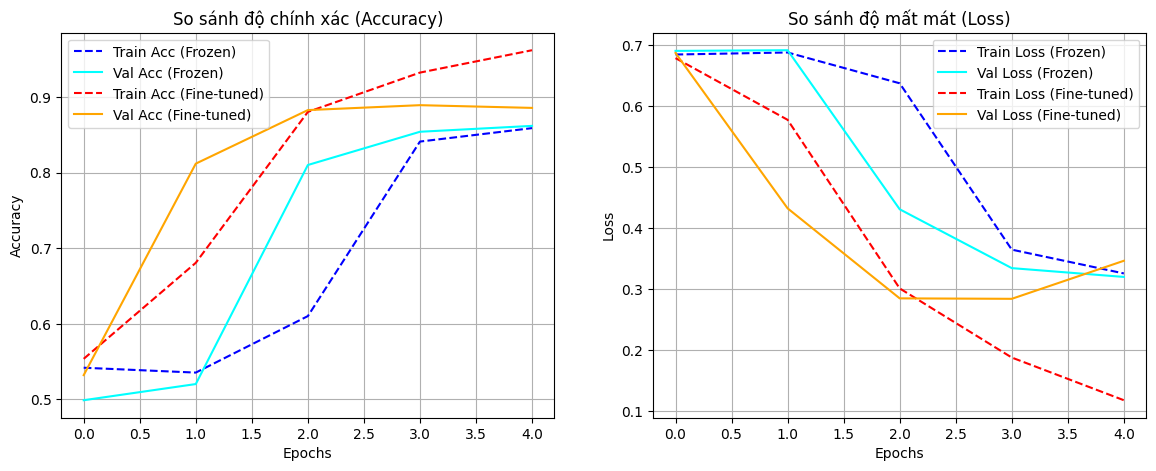

In [85]:
# Ô mã này dùng để vẽ biểu đồ so sánh lịch sử huấn luyện (Loss & Accuracy) của hai mô hình:
# 1. Mô hình Đông băng (Frozen) và 2. Mô hình Cập nhật trọng số (Fine-tuned).

import matplotlib.pyplot as plt

# Vẽ biểu đồ so sánh Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_frozen.history['accuracy'], label='Train Acc (Frozen)', color='blue', linestyle='--')
plt.plot(history_frozen.history['val_accuracy'], label='Val Acc (Frozen)', color='cyan')
plt.plot(history_fine_tuned.history['accuracy'], label='Train Acc (Fine-tuned)', color='red', linestyle='--')
plt.plot(history_fine_tuned.history['val_accuracy'], label='Val Acc (Fine-tuned)', color='orange')
plt.title('So sánh độ chính xác (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Vẽ biểu đồ so sánh Loss
plt.subplot(1, 2, 2)
plt.plot(history_frozen.history['loss'], label='Train Loss (Frozen)', color='blue', linestyle='--')
plt.plot(history_frozen.history['val_loss'], label='Val Loss (Frozen)', color='cyan')
plt.plot(history_fine_tuned.history['loss'], label='Train Loss (Fine-tuned)', color='red', linestyle='--')
plt.plot(history_fine_tuned.history['val_loss'], label='Val Loss (Fine-tuned)', color='orange')
plt.title('So sánh độ mất mát (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [86]:
# Ô mã này dùng để chạy thử nghiệm dự đoán câu bên ngoài và so sánh trực tiếp kết quả giữa 2 mô hình

demo_sentences = [
    "The movie was an absolute masterpiece! I loved every single frame of it.",
    "Worst film of the year. The acting was painful and the pacing was terribly slow.",
    "It was an average film. Not bad, but nothing special either."
]

print("=== SO SÁNH DỰ ĐOÁN GIỮA HAI MÔ HÌNH ===\n")
for i, sentence in enumerate(demo_sentences):
    # Số hóa câu
    vectorized_sentence = vectorizer([sentence])
    
    # Dự đoán bằng mô hình 1 (Frozen)
    pred_frozen = model.predict(vectorized_sentence, verbose=0)[0][0]
    label_frozen = "POSITIVE" if pred_frozen > 0.5 else "NEGATIVE"
    
    # Dự đoán bằng mô hình 2 (Fine-tuned)
    pred_fine_tuned = model_preTrained.predict(vectorized_sentence, verbose=0)[0][0]
    label_fine_tuned = "POSITIVE" if pred_fine_tuned > 0.5 else "NEGATIVE"
    
    print(f"Câu {i+1}: \"{sentence}\"")
    print(f"-> Mô hình 1 (Frozen):     {label_frozen} (Xác suất: {pred_frozen*100:.2f}%)")
    print(f"-> Mô hình 2 (Fine-tuned):  {label_fine_tuned} (Xác suất: {pred_fine_tuned*100:.2f}%)")
    print("-" * 80)

=== SO SÁNH DỰ ĐOÁN GIỮA HAI MÔ HÌNH ===

Câu 1: "The movie was an absolute masterpiece! I loved every single frame of it."
-> Mô hình 1 (Frozen):     POSITIVE (Xác suất: 93.57%)
-> Mô hình 2 (Fine-tuned):  POSITIVE (Xác suất: 96.49%)
--------------------------------------------------------------------------------
Câu 2: "Worst film of the year. The acting was painful and the pacing was terribly slow."
-> Mô hình 1 (Frozen):     NEGATIVE (Xác suất: 1.72%)
-> Mô hình 2 (Fine-tuned):  NEGATIVE (Xác suất: 0.45%)
--------------------------------------------------------------------------------
Câu 3: "It was an average film. Not bad, but nothing special either."
-> Mô hình 1 (Frozen):     NEGATIVE (Xác suất: 14.76%)
-> Mô hình 2 (Fine-tuned):  NEGATIVE (Xác suất: 4.31%)
--------------------------------------------------------------------------------
